# Transport Dimension - Sprint 1 + 2

## What this notebook does

- **Sprint 1:** runs the GTFS extraction pipeline (via `data_extraction/extract_transport.py`) and produces `data/processed/transport_scores.json` for the 5 MVP suburbs.
- **Sprint 2:** EDA on the transport scores, plus correlation with Reddit transport-aspect sentiment. TF-IDF on transport-filtered posts establishes the Traditional NLP baseline for the poster's Traditional vs Modern comparison.

Extraction logic lives in `extract_transport.py` so it can be called deterministically from CI/cron. This notebook is for exploratory data analysis only.

## MVP suburbs
Newtown · Glebe · Redfern · Surry Hills · Haymarket - per `AGENTS.md`.

## 0 - Setup

In [7]:
import json
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make sibling data_extraction package importable
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from data_extraction import extract_transport

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

PROCESSED_DIR = REPO_ROOT / "data" / "processed"
FIG_DIR = Path("./figs")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 1 - Run the extraction pipeline

Invokes `extract_transport.run()` which produces `data/processed/transport_scores.json`. The first run takes 2-5 minutes because `stop_times.txt` is typically 500MB+ and is chunked at 100k rows.

In [8]:
transport_scores = extract_transport.run()

Loading suburbs from C:\Users\PADMASRI\OneDrive - UTS\Desktop\MDSI\ANLP\AT2b\sydney-liveability-ai\data\processed\suburbs.geojson
  5 suburb polygons loaded
Spatial-joining GTFS stops to suburbs


c:\Users\PADMASRI\OneDrive - UTS\Desktop\MDSI\ANLP\AT2b\sydney-liveability-ai\data_extraction\extract_transport.py:82: DtypeWarning: Columns (0: platform_code) have mixed types. Specify dtype option on import or set low_memory=False.
  stops_df = pd.read_csv(RAW_DIR / "stops.txt")


  399 stops within MVP suburbs
Chunking stop_times.txt (chunksize=100,000) for peak-hour events
  24,053 peak-hour stop events
Filtering to weekday services
  7,346 weekday peak-hour events
Scoring suburbs

Wrote C:\Users\PADMASRI\OneDrive - UTS\Desktop\MDSI\ANLP\AT2b\sydney-liveability-ai\data\processed\transport_scores.json
{
  "Glebe": {
    "transport_score": 0.843,
    "avg_services_per_hour": 8.64,
    "stop_count": 69
  },
  "Haymarket": {
    "transport_score": 0.894,
    "avg_services_per_hour": 9.15,
    "stop_count": 130
  },
  "Newtown": {
    "transport_score": 0.969,
    "avg_services_per_hour": 9.92,
    "stop_count": 59
  },
  "Redfern": {
    "transport_score": 0.814,
    "avg_services_per_hour": 8.34,
    "stop_count": 75
  },
  "Surry Hills": {
    "transport_score": 1.0,
    "avg_services_per_hour": 10.24,
    "stop_count": 66
  }
}


# 2A - Transport score EDA

In [9]:
gtfs_df = (
    pd.DataFrame(transport_scores).T
    .reset_index()
    .rename(columns={"index": "suburb"})
    .sort_values("transport_score", ascending=False)
)
gtfs_df

,suburb,transport_score,avg_services_per_hour,stop_count
4,Surry Hills,1.000,10.24,66.0
2,Newtown,0.969,9.92,59.0
1,Haymarket,0.894,9.15,130.0
0,Glebe,0.843,8.64,69.0
3,Redfern,0.814,8.34,75.0


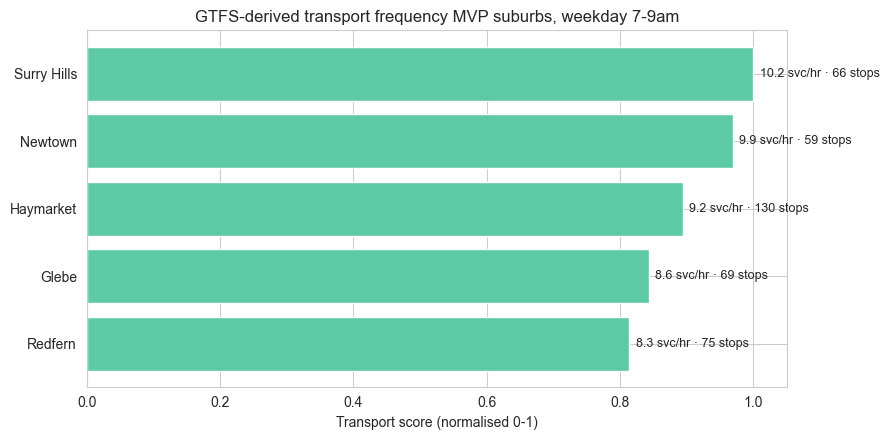

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(gtfs_df["suburb"], gtfs_df["transport_score"], color="#5dcaa5")
ax.invert_yaxis()
ax.set_xlabel("Transport score (normalised 0-1)")
ax.set_title("GTFS-derived transport frequency MVP suburbs, weekday 7-9am")
for i, (_, row) in enumerate(gtfs_df.iterrows()):
    ax.text(
        row["transport_score"] + 0.01, i,
        f"{row['avg_services_per_hour']:.1f} svc/hr · {int(row['stop_count'])} stops",
        va="center", fontsize=9,
    )
plt.tight_layout()
plt.savefig(FIG_DIR / "gtfs_scores.png", dpi=150)
plt.show()

# 2B - Reddit transport sentiment (Traditional NLP baseline)

Aligned with the Reddit pipeline's keyword list: `["train", "bus", "transport"]`. Paths below will need updating once the Reddit sentiment branch merges, both blocks are guarded so the notebook runs end-to-end today on Sprint 1 data alone.

In [11]:
TRANSPORT_KEYWORDS = ["train", "bus", "transport"]

REDDIT_SENTIMENT_PATH = PROCESSED_DIR / "reddit_sentiment_by_aspect.csv"
REDDIT_CORPUS_PATH = PROCESSED_DIR / "reddit_posts.csv"

if REDDIT_SENTIMENT_PATH.exists():
    reddit_aspect_df = pd.read_csv(REDDIT_SENTIMENT_PATH)
    reddit_transport = reddit_aspect_df[reddit_aspect_df["aspect"] == "transport"]
    reddit_transport = reddit_transport[reddit_transport["suburb"].isin(gtfs_df["suburb"])]
    print(f"Transport sentiment rows for MVP: {len(reddit_transport)}")
    print(reddit_transport)
else:
    print(f"Reddit sentiment file not yet at {REDDIT_SENTIMENT_PATH} - skipping correlation block")
    reddit_transport = pd.DataFrame(columns=["suburb", "aspect", "sentiment_score", "post_count"])

Reddit sentiment file not yet at c:\Users\PADMASRI\OneDrive - UTS\Desktop\MDSI\ANLP\AT2b\sydney-liveability-ai\data\processed\reddit_sentiment_by_aspect.csv - skipping correlation block


## TF-IDF on transport-filtered posts

Filter Reddit posts containing transport keywords, then TF-IDF per suburb to surface suburb-specific transport vocabulary. This is the **Traditional** column in the poster comparison.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

if REDDIT_CORPUS_PATH.exists():
    reddit_df = pd.read_csv(REDDIT_CORPUS_PATH)
    reddit_df = reddit_df[reddit_df["suburb"].isin(gtfs_df["suburb"])]

    pattern = "|".join(rf"\b{kw}\b" for kw in TRANSPORT_KEYWORDS)
    transport_posts = reddit_df[reddit_df["text"].str.contains(pattern, case=False, na=False)]
    print(f"Transport-mentioning posts: {len(transport_posts):,} / {len(reddit_df):,}")

    tfidf_terms = {}
    for suburb, group in transport_posts.groupby("suburb"):
        if len(group) < 5:
            print(f"  {suburb}: skipped ({len(group)} posts)")
            continue
        vec = TfidfVectorizer(max_features=50, stop_words="english", ngram_range=(1, 2), min_df=2)
        X = vec.fit_transform(group["text"].fillna(""))
        scores = X.mean(axis=0).A1
        terms = vec.get_feature_names_out()
        tfidf_terms[suburb] = sorted(zip(terms, scores), key=lambda x: -x[1])[:10]

    for suburb, top in tfidf_terms.items():
        print(f"\n{suburb} top transport terms:")
        for term, score in top:
            print(f"  {term:30s} {score:.3f}")
else:
    print(f"Reddit corpus not yet at {REDDIT_CORPUS_PATH}")
    tfidf_terms = {}

Reddit corpus not yet at c:\Users\PADMASRI\OneDrive - UTS\Desktop\MDSI\ANLP\AT2b\sydney-liveability-ai\data\processed\reddit_posts.csv


# 2C - Objective vs subjective correlation

Does GTFS frequency predict Reddit sentiment? With only 5 MVP suburbs the Pearson r is directional rather than statistically powerful, but either outcome is a defensible finding:

- Positive: objective frequency drives resident perception
- Flat / negative: residents care about reliability, crowding, or safety, not just frequency

In [13]:
if len(reddit_transport) > 0:
    merged = gtfs_df.merge(
        reddit_transport[["suburb", "sentiment_score", "post_count"]],
        on="suburb", how="left"
    ).dropna(subset=["sentiment_score"])

    if len(merged) >= 3:
        fig, ax = plt.subplots(figsize=(8, 6))
        sizes = merged["post_count"].fillna(10).clip(lower=30)
        ax.scatter(merged["transport_score"], merged["sentiment_score"],
                   s=sizes * 3, alpha=0.6, color="#378add")
        for _, row in merged.iterrows():
            ax.annotate(row["suburb"], (row["transport_score"], row["sentiment_score"]),
                        xytext=(5, 5), textcoords="offset points", fontsize=10)
        ax.set_xlabel("GTFS transport score (objective: service frequency)")
        ax.set_ylabel("Reddit transport sentiment (subjective: VADER)")
        ax.set_title("Do residents feel the transport matches its frequency?")
        ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.savefig(FIG_DIR / "transport_correlation.png", dpi=150)
        plt.show()

        r = merged[["transport_score", "sentiment_score"]].corr().iloc[0, 1]
        print(f"\nPearson r: {r:+.3f}")
    else:
        print("Not enough paired data points, rerun once the Reddit sentiment file merges")
else:
    print("Skipping, Reddit sentiment not yet available")

Skipping, Reddit sentiment not yet available
